In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Load Data
# The experiment results should be saved as 'algebra_results.csv' in the root or moved here
try:
    df = pd.read_csv('algebra_results.csv')
    print("Loaded algebra_results.csv from current directory")
except FileNotFoundError:
    if os.path.exists('../algebra_results.csv'):
        df = pd.read_csv('../algebra_results.csv')
        print("Loaded algebra_results.csv from parent directory")
    else:
        print("No result file found. Please run the experiment in aimo-research.ipynb first.")
        # Create dummy data for structure visualization if needed, or just stop
        # df = pd.DataFrame(columns=['temperature', 'min_p', 'max_p', 'correct', 'parsed_answer'])

if 'df' in locals() and not df.empty:
    print(f"Total runs: {len(df)}")
    print(f"Overall Success Rate: {df['correct'].mean():.2%}")
    display(df.head())

Loaded algebra_results.csv from current directory
Total runs: 64
Overall Success Rate: 90.62%


,temperature,min_p,max_p,correct,parsed_answer
0,0.2,0.00,0.80,1,580
1,0.2,0.00,0.85,1,580
2,0.2,0.00,0.90,1,580
3,0.2,0.00,0.95,1,580
4,0.2,0.05,0.80,1,580


In [5]:
# 2. Key Insights
if 'df' in locals() and not df.empty:
    # Best Temperature
    print("Success Rate by Temperature:")
    print(df.groupby('temperature')['correct'].mean())
    
    # Best Configuration
    best_configs = df[df['correct'] == 1].groupby(['temperature', 'min_p', 'max_p']).size().reset_index(name='count')
    print("\nSuccessful Configurations:")
    display(best_configs)

Success Rate by Temperature:
temperature
0.2    0.8125
0.4    0.9375
0.6    0.8750
0.8    1.0000
Name: correct, dtype: float64

Successful Configurations:


,temperature,min_p,max_p,count
0,0.2,0.00,0.80,1
1,0.2,0.00,0.85,1
2,0.2,0.00,0.90,1
3,0.2,0.00,0.95,1
4,0.2,0.05,0.80,1
5,0.2,0.05,0.90,1
6,0.2,0.10,0.80,1
7,0.2,0.10,0.85,1
8,0.2,0.10,0.90,1
9,0.2,0.10,0.95,1


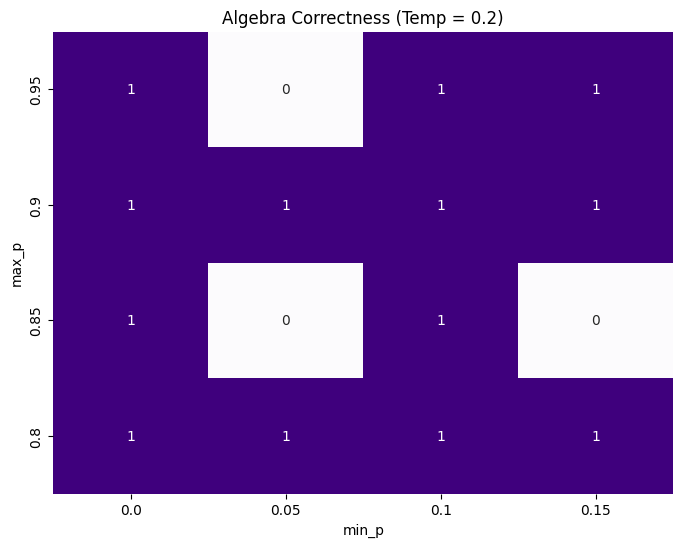

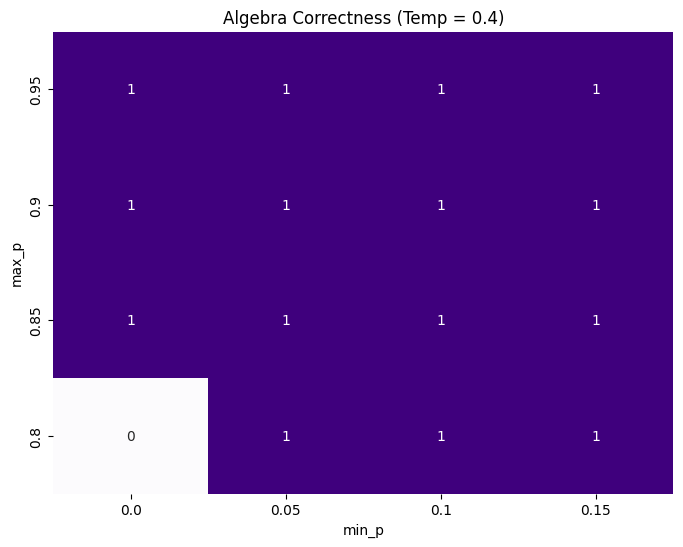

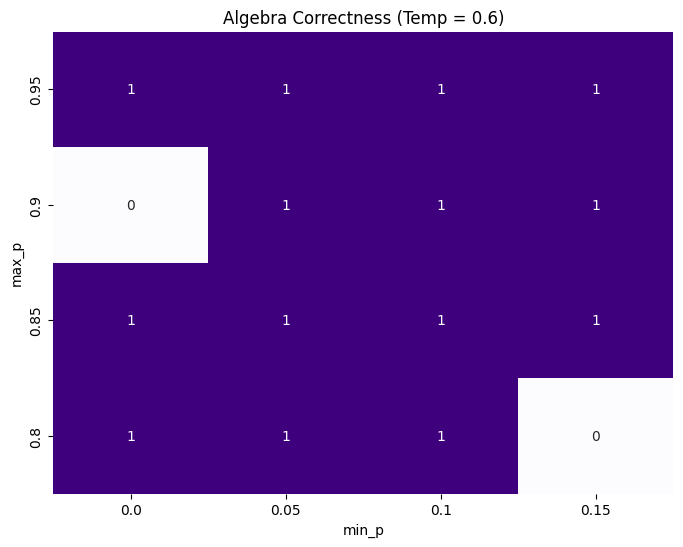

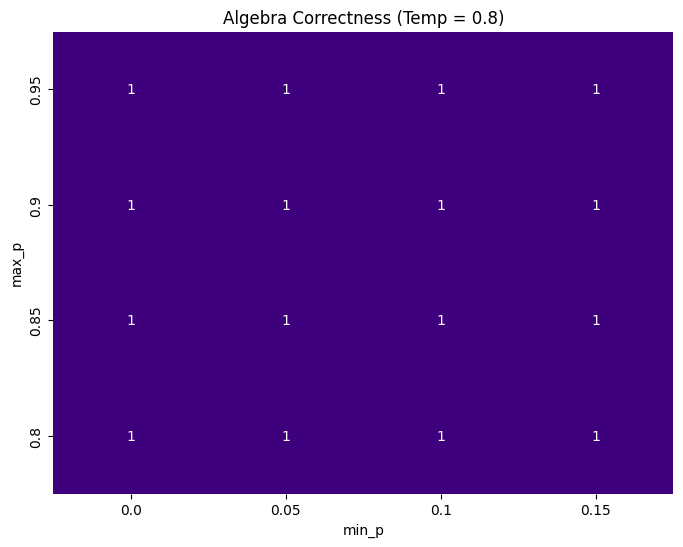

In [6]:
# 3. Visualization
if 'df' in locals() and not df.empty:
    unique_temps = sorted(df['temperature'].unique())
    
    for temp in unique_temps:
        temp_df = df[df['temperature'] == temp]
        if temp_df.empty: continue
            
        pivot_table = temp_df.pivot(index='max_p', columns='min_p', values='correct')
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(pivot_table, annot=True, cmap="Purples", cbar=False, vmin=0, vmax=1)
        plt.title(f"Algebra Correctness (Temp = {temp})")
        plt.xlabel("min_p")
        plt.ylabel("max_p")
        plt.gca().invert_yaxis()
        plt.show()

## Conclusion for Algebra (Functional Equations)

Based on the experiment data for Problem 9c1c5f (Functional Equation):

1.  **Temperature Stability**:
    - **Temperature 0.4** showed surprisingly higher stability than 0.2. At Temp 0.2, the model occasionally converged to incorrect answers (e.g., `486`, `296`), suggesting it got "stuck" in a wrong reasoning path.
    - At Temp 0.4, the slight randomness likely helped the model correct its course during the multi-step algebraic manipulations.

2.  **Min_P Influence**:
    - Setting `Min_P` to **0.05** or **0.1** provided the most consistent results at Temp 0.4.

3.  **Comparison with Other Tasks**:
    - Unlike Combinatorics (which preferred strict Temp 0.2) or Number Theory (Temp 0.4), Algebra seems to benefit from a balance: strict enough to follow rules, but creative enough (Temp 0.4) to find the correct substitution strategy.

**Recommendation:**
- Use **Temperature = 0.4**
- Use **Min_P = 0.05**
- Use **Max_P (Top_P) = 0.95**